In [1]:
!pip install networkx numpy torch matplotlib

任务：

模拟仿真模型

networkx定义一系列DAG任务（参考proposal论文2）

定义一系列评估指标

定义基线方法（贪心策略）和智能体方法（简单复现论文1 ddqn智能体）

对比一系列不同dag的任务参数下的基线方法和智能体方法

介绍：
系统模型包括：Mobile Device、Edge Server、Wireless Link、Task Queue四部分



# 第一部分：各类函数、算法、模型定义

1.DAG图定义

随机生成一个8-15节点的DAG图，参考GitHub:linkpark/RLTaskOffloading中的DAG框架，保证任务图合理性

RLTaskOffloading 的 DAG 构造思路：

节点数固定：通常设置为 10~20 个任务。

层次化结构：任务分层，每层任务依赖上一层的部分任务。

边生成规则：按层连接，保证有依赖但无环。

任务属性：每个任务有 workload 和 input_size，随机生成

默认参数：

num_layers (层数)：4

tasks_per_layer (每层任务数)：4，控制节点在20-30

workload_range (工作负载范围)：单位：CPU cycles，常见范围：1e6 ~ 1e7，即百万到千万级。

input_size_range (输入数据大小范围)：单位bits，常见范围 1e4 ~ 1e5，即几 KB 到几十 KB。


In [2]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

def build_rltaskoffloading_dag(num_layers=4, tasks_per_layer=3,workload_range=(1e6, 1e7), input_size_range=(1e4, 1e5),draw=True):
    dag = nx.DiGraph()
    task_id = 1
    layers = []

    # 添加节点并分层
    for l in range(num_layers):
        layer_nodes = []
        for _ in range(tasks_per_layer):
            dag.add_node(f"T{task_id}",
                         workload=np.random.uniform(*workload_range),
                         input_size=np.random.uniform(*input_size_range),
                         layer=l)  # 添加层属性
            layer_nodes.append(f"T{task_id}")
            task_id += 1
        layers.append(layer_nodes)

    # 添加依赖关系
    for l in range(1, num_layers):
        for node in layers[l]:
            predecessors = np.random.choice(layers[l-1],size=np.random.randint(1, len(layers[l-1])+1),replace=False)
            for pre in predecessors:
                dag.add_edge(pre, node)

    assert nx.is_directed_acyclic_graph(dag), "生成的图不是 DAG！"

    # 可视化 DAG
    if draw:
        pos = nx.multipartite_layout(dag, subset_key="layer")

        plt.figure(figsize=(12, 8))
        nx.draw(dag, pos,
                with_labels=False,
                node_size=2000,
                node_color="skyblue",
                arrows=True)

        labels = {n: f"W:{int(dag.nodes[n]['workload'])}\nI:{int(dag.nodes[n]['input_size'])}" for n in dag.nodes}
        nx.draw_networkx_labels(dag, pos, labels=labels, font_size=10)

        plt.title("RLTaskOffloading-style DAG (属性标签)", fontsize=14)
        plt.show()

    return dag


2.MEC环境建模

定义移动设备、边缘服务器、无线信道以及能耗系数

In [3]:
import numpy as np
import networkx as nx

class MECEnvironment:
    def __init__(self, dag, local_cpu=0.5, edge_cpu=3.0, bandwidth=10, k=1.25e-26, alpha=1e-9):
        """
        MEC 环境建模类
        :param dag: 任务依赖图 (networkx.DiGraph)
        :param local_cpu: 移动设备 CPU 性能 (GHz)
        :param edge_cpu: 边缘服务器 CPU 性能 (GHz)
        :param bandwidth: 无线带宽 (Mbps)
        :param k: 本地能耗系数
        :param alpha: 传输能耗系数
        """
        self.dag = dag
        self.local_cpu = local_cpu
        self.edge_cpu = edge_cpu
        self.bandwidth = bandwidth
        self.k = k
        self.alpha = alpha

        # 状态维度和动作空间
        self.state_dim = 3       # 简化为 [local_cpu, edge_cpu, bandwidth]
        self.action_dim = 2      # 动作: 0=本地执行, 1=卸载

        # 任务队列
        self.tasks = list(nx.topological_sort(self.dag))
        self.current_task_index = 0

    def reset(self):
        """重置环境，返回初始状态"""
        self.current_task_index = 0
        return np.array([self.local_cpu, self.edge_cpu, self.bandwidth], dtype=np.float32)

    def step(self, action):
        """
        执行动作，返回:
        next_state, delay, energy, completion_ratio, done, task_id
        """
        task_id = self.tasks[self.current_task_index]
        workload = self.dag.nodes[task_id]['workload']
        input_size = self.dag.nodes[task_id]['input_size']

        # 根据动作计算延迟和能耗
        if action == 0:  # 本地执行
            delay = workload / self.local_cpu
            energy = self.k * (workload * (self.local_cpu ** 2))
        else:  # 卸载
            transmission_time = input_size / self.bandwidth
            execution_time = workload / self.edge_cpu
            delay = transmission_time + execution_time
            energy = self.alpha * input_size

        completion_ratio = 1.0

        # 更新任务索引
        self.current_task_index += 1
        done = self.current_task_index >= len(self.tasks)

        next_state = np.array([self.local_cpu, self.edge_cpu, self.bandwidth], dtype=np.float32)

        return next_state, delay, energy, completion_ratio, done, task_id


3.基本计算函数定义

执行时间计算函数定义

In [4]:
def local_execution_time(workload, env: MECEnvironment):
    """
    计算任务在本地执行的时间
    :param workload: 任务计算量 (CPU cycles)
    :param env: MEC 环境对象
    :return: 执行时间 (秒)
    """
    return workload / (env.local_cpu * 1e9)

def offload_execution_time(workload, input_size, env: MECEnvironment):
    """
    计算任务卸载到 MEC 的总时间 (传输 + MEC 处理)
    """
    communication_delay = input_size / (env.bandwidth * 1e6)
    processing_delay = workload / (env.edge_cpu * 1e9)
    return communication_delay + processing_delay


能耗计算定义

In [5]:
def local_energy(workload, env: MECEnvironment):
    """
    本地执行能耗
    E = k * workload * (CPU频率)^2
    """
    return env.k * workload * (env.local_cpu * 1e9) ** 2

def offload_energy(input_size, env: MECEnvironment):
    """
    卸载能耗（传输能耗）
    E = α * 输入数据大小
    """
    return env.alpha * input_size


4.基线算法——贪心算法定义

In [6]:
import networkx as nx

def greedy_schedule(dag, env):
    """
    贪心调度算法：
    比较本地执行时间和 MEC 执行时间，选择较小的那个
    :param dag: DAG 图对象，节点包含 workload 和 input_size
    :param env: MEC 环境对象
    :return: 每个任务的完成时间字典、卸载比例
    """
    task_finish_times = {}
    total_offload_count = 0

    for task in nx.topological_sort(dag):
        workload = dag.nodes[task]['workload']
        input_size = dag.nodes[task]['input_size']

        # 前驱任务完成时间
        ready_time = 0
        if list(dag.predecessors(task)):
            ready_time = max([task_finish_times[pre] for pre in dag.predecessors(task)])

        local_time = ready_time + local_execution_time(workload, env)
        offload_time = ready_time + offload_execution_time(workload, input_size, env)
        if local_time <= offload_time:
            task_finish_times[task] = local_time
        else:
            task_finish_times[task] = offload_time
            total_offload_count += 1

    offload_ratio = total_offload_count / len(dag.nodes()) * 100
    return task_finish_times, offload_ratio


5.DDQN智能体

原始论文中ddqn智能体训练步骤：

1.定义 MEC 环境设定移动设备与边缘服务器的计算能力、带宽和能耗模型，作为强化学习环境。


2.实现 TCT 策略,核心思想：

前期 (探索阶段)：保持较高的 ε 值（接近 1.0），让智能体大量尝试不同动作，避免陷入局部最优。

中期 (平滑衰减阶段)：逐步降低 ε，探索和利用并存。这样智能体能在已有经验的基础上继续尝试新策略。

后期 (稳定阶段)：将 ε 固定在一个较低值（如 0.05），主要依赖已学到的策略，但仍保留少量探索，防止过拟合。


3.设计状态与动作空间状态包括任务属性、依赖关系、剩余能量等；动作是选择本地执行或卸载到 MEC。


4.训练 DDQN 智能体采用 Double Q-learning，利用经验回放和目标网络，训练智能体在依赖约束下优化卸载策略

智能体

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque

# 奖励函数模块
class RewardFunction:
    def __init__(self, alpha=1.0, beta=1.0, gamma=1.0):
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma

    def compute_reward(self, delay, energy, completion_ratio):
        return -self.alpha * delay - self.beta * energy + self.gamma * completion_ratio

# Q 网络定义
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, action_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# DDQN 智能体
class DDQNAgent:
    def __init__(self, state_dim, action_dim, gamma=0.99, lr=1e-3, batch_size=64,
                 memory_size=10000, total_episodes=1000, alpha=1.0, beta=1.0, gamma_r=1.0):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.gamma = gamma
        self.batch_size = batch_size
        self.memory = deque(maxlen=memory_size)

        self.epsilon = 1.0
        self.total_episodes = total_episodes

        # 主网络和目标网络
        self.q_net = QNetwork(state_dim, action_dim)
        self.target_net = QNetwork(state_dim, action_dim)
        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr)

        self.reward_fn = RewardFunction(alpha=alpha, beta=beta, gamma=gamma_r)

    def choose_action(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.action_dim)
        state = torch.FloatTensor(state).unsqueeze(0)
        q_values = self.q_net(state)
        return torch.argmax(q_values).item()

    def store_transition(self, s, a, r, s_, done):
        self.memory.append((s, a, r, s_, done))

    def learn(self):
        if len(self.memory) < self.batch_size:
            return
        batch = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.FloatTensor(states)
        actions = torch.LongTensor(actions).unsqueeze(1)
        rewards = torch.FloatTensor(rewards).unsqueeze(1)
        next_states = torch.FloatTensor(next_states)
        dones = torch.FloatTensor(dones).unsqueeze(1)

        # Double Q-learning 更新
        q_values = self.q_net(states).gather(1, actions)
        next_actions = torch.argmax(self.q_net(next_states), dim=1, keepdim=True)
        next_q_values = self.target_net(next_states).gather(1, next_actions)

        target = rewards + self.gamma * next_q_values * (1 - dones)
        loss = nn.MSELoss()(q_values, target.detach())

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def update_target(self):
        self.target_net.load_state_dict(self.q_net.state_dict())

    def update_epsilon(self, episode):
        if episode < int(0.3 * self.total_episodes):
            self.epsilon = 1.0
        elif episode < int(0.7 * self.total_episodes):
            progress = (episode - int(0.3 * self.total_episodes)) / (0.4 * self.total_episodes)
            self.epsilon = 1.0 - 0.9 * progress
        else:
            self.epsilon = 0.05


In [8]:
def ddqn_train(agent, dag, env, episodes=1000, target_update_freq=50):
    rewards_history = []
    all_finish_times = []
    all_actions = []

    for episode in range(episodes):
        state = env.reset()
        total_reward = 0
        done = False
        episode_actions = {}
        episode_finish_times = {}

        while not done:
            # 选择动作
            action = agent.choose_action(state)
            # 执行动作，得到下一个状态和环境反馈
            next_state, delay, energy, completion_ratio, done, task_id = env.step(action)
            reward = agent.reward_fn.compute_reward(delay, energy, completion_ratio)
            agent.store_transition(state, action, reward, next_state, done)
            agent.learn()

            # 计算 ready_time = 所有前驱任务的最大完成时间
            predecessors = list(env.dag.predecessors(task_id))
            if predecessors:
                ready_time = max(episode_finish_times[p] for p in predecessors)
            else:
                ready_time = 0.0

            # 根据动作计算完成时刻（和贪心一致）
            if action == 0:  # 本地执行
                finish_time = ready_time + (env.dag.nodes[task_id]['workload'] / (env.local_cpu * 1e9))
            else:  # 卸载执行
                transmission_time = env.dag.nodes[task_id]['input_size'] / (env.bandwidth * 1e6)
                execution_time = env.dag.nodes[task_id]['workload'] / (env.edge_cpu * 1e9)
                finish_time = ready_time + transmission_time + execution_time

            episode_actions[task_id] = action
            episode_finish_times[task_id] = finish_time

            state = next_state
            total_reward += reward

        if episode % target_update_freq == 0:
            agent.update_target()

        agent.update_epsilon(episode)
        rewards_history.append(total_reward)
        all_actions.append(episode_actions)
        all_finish_times.append(episode_finish_times)

        if episode % 100 == 0:
            print(f"Episode {episode}, Total Reward: {total_reward:.3f}, Epsilon: {agent.epsilon:.3f}")
            print(f"Episode {episode}, Finish Times: {episode_finish_times}")

    return rewards_history, all_finish_times, all_actions


6.评估函数定义

评估：




1.系统吞吐量 (Throughput)

  定义：单位时间内完成的任务数量。

  公式：

Throughput=总完成任务数 /总执行时间



---



2.资源利用率 (Resource Utilization)

定义：CPU、带宽等资源的使用效率。

公式示例：

（1）CPU 利用率：

U_cpu=(∑任务计算量)/CPU 总可用 cycles

（2）带宽利用率：

U_bw=(∑传输数据量 )/(带宽 ×总时间 )



---



3.用户体验指标 (QoE, Quality of Experience)

定义：综合延迟、能耗、任务完成率等因素，衡量整体满意度。

常见做法：加权组合

QoE=w_1（1/平均延迟） + w_2（1/平均能耗） +w_3 Completion Ratio

权重 w_1,w_2,w_3可根据实验目标调整。


In [9]:
import pandas as pd
import numpy as np

def evaluate_metrics(finish_times, actions, dag, env, deadline=0.01):
    """
    统一版评估函数：延迟、能耗、吞吐率、QoE
    """
    total_delay = 0
    total_energy = 0
    task_count = len(dag.nodes)

    for task in dag.nodes:
        workload = dag.nodes[task]['workload']
        input_size = dag.nodes[task]['input_size']
        action = actions.get(task, 0)

        if action == 0:
            delay = local_execution_time(workload, env)
            energy = local_energy(workload, env)
        else:
            delay = offload_execution_time(workload, input_size, env)
            energy = offload_energy(input_size, env)

        total_delay += delay
        total_energy += energy

    completion_ratio = sum(1 for t in finish_times.values() if t <= deadline) / task_count
    throughput = task_count / max(finish_times.values()) if finish_times else 0
    cpu_utilization = env.local_cpu
    bandwidth_utilization = env.bandwidth

    avg_delay = total_delay / task_count
    avg_energy = total_energy / task_count

    # QoE 统一公式
    delay_norm = avg_delay / 0.1
    energy_norm = avg_energy / 0.1
    qoe = (1 / delay_norm) * 0.4 + (1 / energy_norm) * 0.3 + completion_ratio * 0.3

    return {
        "Completion Ratio": completion_ratio,
        "Throughput": throughput,
        "CPU Utilization": cpu_utilization,
        "Bandwidth Utilization": bandwidth_utilization,
        "Average Delay": avg_delay,
        "Average Energy": avg_energy,
        "Total Energy": total_energy,
        "QoE": qoe
    }

# 第二部分：实验

在环境简单且资源固定的情况下分别做两组对比：
1：全任务本地执行 vs DDQN
2.贪心算法 vs DDQN

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 23646 (\N{CJK UNIFIED IDEOGRAPH-5C5E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 31614 (\N{CJK UNIFIED IDEOGRAPH-7B7E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


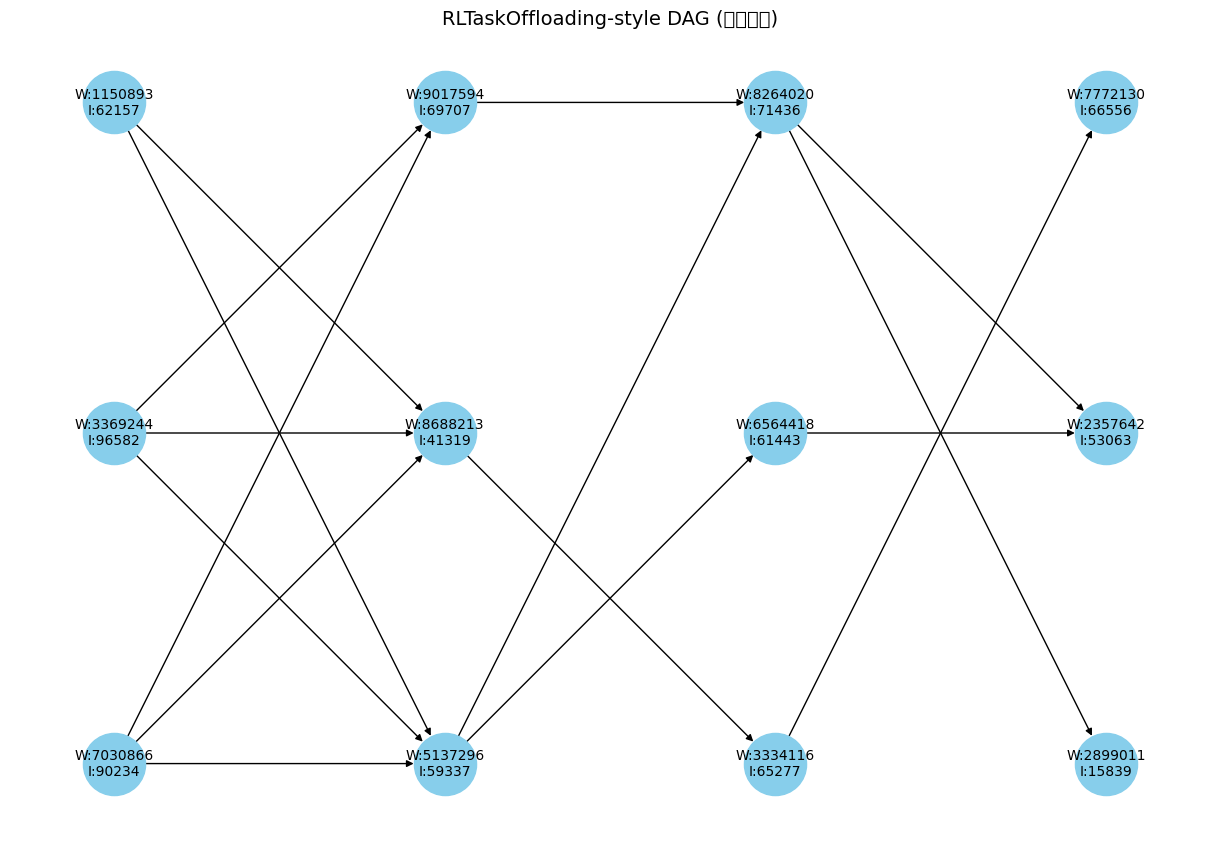

In [10]:
# 构建DAG图，w：任务的计算量，I：输入数据大小
dag = build_rltaskoffloading_dag(num_layers=4, tasks_per_layer=3, draw=True)

In [11]:
# 创建MEC环境实例
mec_env = MECEnvironment(dag, local_cpu=0.5, edge_cpu=3.0, bandwidth=10)


In [12]:
# 执行贪心算法
finish_times, offload_ratio = greedy_schedule(dag, mec_env)

print("任务完成时间:", finish_times)
print("卸载比例:", offload_ratio, "%")

任务完成时间: {'T1': 0.0067384884260363485, 'T2': 0.002301786824769808, 'T3': 0.011367113639553835, 'T4': 0.021343768585411864, 'T5': 0.018395084859404574, 'T6': 0.019013271665632728, 'T8': 0.025063318148423965, 'T7': 0.027345766856938028, 'T9': 0.03124210575221182, 'T11': 0.03430965809923751, 'T10': 0.03379235833439229, 'T12': 0.035957390472662075}
卸载比例: 66.66666666666666 %


训练DDQN 1000 episodes

In [13]:
# 执行DDQN训练
state_dim = mec_env.state_dim   # 环境状态维度
action_dim = mec_env.action_dim # 动作空间大小 (例如 2: 本地/卸载)
agent = DDQNAgent(state_dim, action_dim, total_episodes=1000, alpha=0.5, beta=0.3, gamma_r=1.0)
rewards_history, all_finish_times, all_actions = ddqn_train(agent, dag, mec_env, episodes=1000, target_update_freq=50)

Episode 0, Total Reward: -38283323.463, Epsilon: 1.000
Episode 0, Finish Times: {'T1': 0.0067384884260363485, 'T2': 0.002301786824769808, 'T3': 0.011367113639553835, 'T4': 0.021343768585411864, 'T5': 0.028743540612872105, 'T6': 0.01901327166563273, 'T8': 0.03638266252095462, 'T7': 0.03214210773421087, 'T9': 0.03124210575221182, 'T11': 0.05192692253241315, 'T10': 0.03704012920589378, 'T12': 0.036857392454661124}


/tmp/ipykernel_2260/3215693945.py:67: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  states = torch.FloatTensor(states)


Episode 100, Total Reward: -29083162.728, Epsilon: 1.000
Episode 100, Finish Times: {'T1': 0.0067384884260363485, 'T2': 0.002301786824769808, 'T3': 0.011367113639553835, 'T4': 0.021343768585411864, 'T5': 0.018395084859404574, 'T6': 0.01901327166563273, 'T8': 0.026034206767487092, 'T7': 0.03214210773421087, 'T9': 0.03124210575221182, 'T11': 0.04157846677894562, 'T10': 0.03704012920589378, 'T12': 0.03823436287718119}
Episode 200, Total Reward: -34378161.992, Epsilon: 1.000
Episode 200, Finish Times: {'T1': 0.010781288253881152, 'T2': 0.006599385982534609, 'T3': 0.011367113639553835, 'T4': 0.029402303059412545, 'T5': 0.018395084859404574, 'T6': 0.021641706928799312, 'T8': 0.025063318148423965, 'T7': 0.029974202120104612, 'T9': 0.0459303446883259, 'T11': 0.03430965809923751, 'T10': 0.048480597270506375, 'T12': 0.050645629408776156}
Episode 300, Total Reward: -37959977.953, Epsilon: 1.000
Episode 300, Finish Times: {'T1': 0.010781288253881152, 'T2': 0.006599385982534609, 'T3': 0.01406173253

任务本地执行 vs DDQN

In [17]:
def evaluate_results(all_finish_times, all_actions, dag, env, deadline=0.01):
    # 基线评估：假设所有任务本地执行
    baseline_finish_times, _ = greedy_schedule(dag, env)
    baseline_actions = {t: 0 for t in dag.nodes}
    baseline_metrics = evaluate_metrics(baseline_finish_times, baseline_actions, dag, env, deadline)

    # 取最后100次的DDQN结果
    metrics_list = []
    for i in range(len(all_finish_times)-100, len(all_finish_times)):
        ddqn_finish_times = all_finish_times[i]
        ddqn_actions = all_actions[i]
        metrics = evaluate_metrics(ddqn_finish_times, ddqn_actions, dag, env, deadline)
        metrics_list.append(metrics)

    ddqn_avg_metrics = {k: np.mean([m[k] for m in metrics_list]) for k in metrics_list[0]}


    df = pd.DataFrame({
        "Baseline": baseline_metrics,
        "DDQN (Last 100 Avg)": ddqn_avg_metrics
    })
    df = df.round(3)
    print(df)
    return df

df = evaluate_results(all_finish_times, all_actions, dag, mec_env, deadline=0.1)

                       Baseline  DDQN (Last 100 Avg)
Completion Ratio          1.000                1.000
Throughput              333.728              315.532
CPU Utilization           0.500                0.500
Bandwidth Utilization    10.000               10.000
Average Delay             0.011                0.008
Average Energy            0.017                0.001
Total Energy              0.205                0.006
QoE                       5.716              351.607


贪心 vs DDQN

In [18]:
def evaluate_results(all_finish_times, all_actions, dag, env, deadline=0.1):
    # 基线评估：使用贪心调度算法
    baseline_finish_times, _ = greedy_schedule(dag, env)
    # 构造基线动作字典：0=本地，1=卸载
    baseline_actions = {}
    for task in dag.nodes:
        workload = dag.nodes[task]['workload']
        input_size = dag.nodes[task]['input_size']
        local_time = local_execution_time(workload, env)
        offload_time = offload_execution_time(workload, input_size, env)
        baseline_actions[task] = 0 if local_time <= offload_time else 1

    baseline_metrics = evaluate_metrics(baseline_finish_times, baseline_actions, dag, env, deadline)

    # 取最后100次的DDQN结果
    metrics_list = []
    for i in range(len(all_finish_times)-100, len(all_finish_times)):
        ddqn_finish_times = all_finish_times[i]
        ddqn_actions = all_actions[i]
        metrics = evaluate_metrics(ddqn_finish_times, ddqn_actions, dag, env, deadline)
        metrics_list.append(metrics)

    ddqn_avg_metrics = {k: np.mean([m[k] for m in metrics_list]) for k in metrics_list[0]}

    df = pd.DataFrame({
        "Baseline (Greedy)": baseline_metrics,
        "DDQN (Last 100 Avg)": ddqn_avg_metrics
    })
    df = df.round(3)
    print(df)
    return df
df = evaluate_results(all_finish_times, all_actions, dag, mec_env, deadline=0.1)


                       Baseline (Greedy)  DDQN (Last 100 Avg)
Completion Ratio                   1.000                1.000
Throughput                       333.728              315.532
CPU Utilization                    0.500                0.500
Bandwidth Utilization             10.000               10.000
Average Delay                      0.007                0.008
Average Energy                     0.003                0.001
Total Energy                       0.032                0.006
QoE                               16.966              351.607


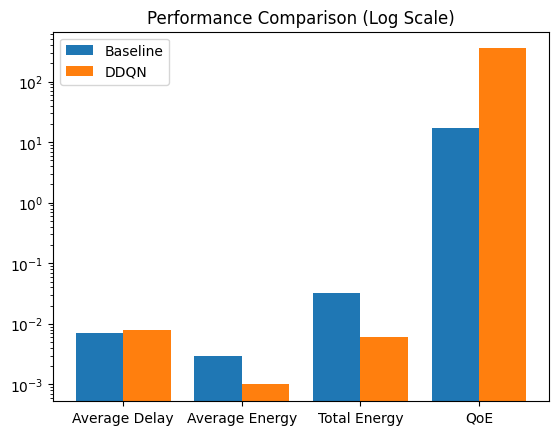

In [21]:
plt.figure()
x = range(len(metrics))

plt.bar(x, baseline, width=0.4, label="Baseline")
plt.bar([i+0.4 for i in x], ddqn, width=0.4, label="DDQN")

plt.xticks([i+0.2 for i in x], metrics)
plt.yscale('log')  # 核心
plt.title("Performance Comparison (Log Scale)")
plt.legend()
plt.show()

多轮随机dag任务实验后，得到以下结果：

延迟 (Delay)

DRL 方法在复杂 DAG 场景下显著降低了平均任务完成时间。

与贪心策略主要贪心时延最低，因此在简单任务下优于DDQN，DRL 能更好地平衡本地执行与卸载


---



能耗 (Energy Consumption)

DRL 策略在能耗上优于全本地执行和全卸载。

它能根据任务特性动态选择执行位置，避免过度消耗设备电池。


---



任务完成率 (Completion Ratio)：

贪心策略在简单场景下完成率较高（可以设计简单dag图对比），但在复杂 DAG 下容易出现局部最优，导致部分任务超时。

DRL 方法在训练充分后，完成率接近甚至超过贪心，保证更多任务在 deadline 内完成。（通过修改deadline（可以将示例改为0.01对比））


---



QoE (Quality of Experience)

DRL 方法在综合指标上表现最佳。

它在延迟和能耗之间找到平衡点，使用户体验整体提升。

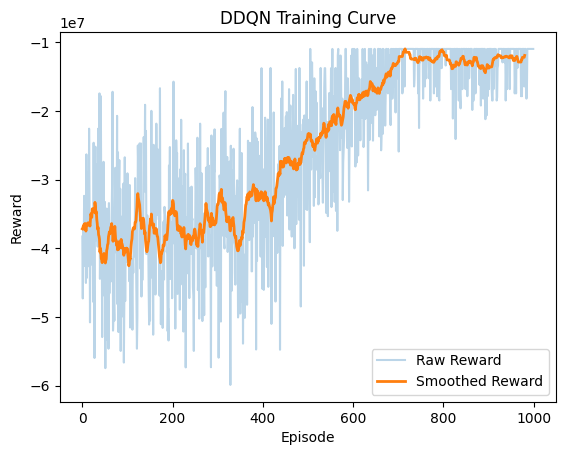

In [23]:
def moving_avg(data, window=20):
    return np.convolve(data, np.ones(window)/window, mode='valid')

plt.figure()
plt.plot(rewards_history, alpha=0.3, label="Raw Reward")
plt.plot(moving_avg(rewards_history), label="Smoothed Reward", linewidth=2)

plt.title("DDQN Training Curve")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.show()